# MaxDiff (Best-Worst Scaling)

MaxDiff is a survey methodology for ranking a large pool of items by preference. Respondents see
rotating subsets of the items and, for each subset, pick the **best** and **worst**. The method
has become a workhorse in conjoint / pricing / product research because it:

- Avoids the well-known biases of rating scales (scale use heterogeneity, acquiescence).
- Forces discrimination — respondents cannot rate everything "important".
- Recovers item utilities on a common scale that supports *share-of-preference* calculations.

This notebook walks through hierarchical Bayesian MaxDiff with
[`MaxDiffMixedLogit`](../../api/generated/pymc_marketing.customer_choice.MaxDiffMixedLogit.rst):
synthetic data → model fit → recovery diagnostics → respondent heterogeneity →
share-of-preference output.


In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from pymc_marketing.customer_choice import (
    MaxDiffMixedLogit,
    generate_maxdiff_data,
)

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
%config InlineBackend.figure_format = "retina"

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100

SEED = 42
rng = np.random.default_rng(SEED)

## Model

For each task $t$ a respondent $r$ sees a subset $S_t$ of the item pool and picks a best item $b_t$
and worst item $w_t$. The Louviere *sequential best-worst* likelihood decomposes the joint pick as

$$
P(b_t, w_t \mid S_t) = \underbrace{\mathrm{softmax}_{j \in S_t}(U_{rj})_{b_t}}_{\text{best pick}} \times
\underbrace{\mathrm{softmax}_{j \in S_t \setminus \{b_t\}}(-U_{rj})_{w_t}}_{\text{worst pick (sign-flipped)}}.
$$

Item utilities $U_{rj}$ decompose into a population-level item intercept plus a per-respondent deviation:

$$
U_{rj} = \beta_j + \sigma_j z_{rj}, \qquad z_{rj} \sim \mathcal{N}(0, 1),
$$

with the reference item pinned to $\beta_{\text{ref}} = 0$ for identification. Only utility
*contrasts* against the reference item are identified — absolute utility levels are arbitrary.


## Synthetic data

`generate_maxdiff_data` draws subsets uniformly at random (a real field design would use a
balanced incomplete block design) and simulates best / worst picks under the Louviere model.
It returns a long-format `DataFrame` and a dictionary of the true utilities we want to recover.


In [3]:
task_df, ground_truth = generate_maxdiff_data(
    n_respondents=200,
    n_items=10,
    n_tasks_per_resp=12,
    subset_size=4,
    sigma_respondent=0.4,
    random_seed=SEED,
)

items = ground_truth["items"]
true_utilities = ground_truth["utilities"]
task_df.head()

,respondent_id,task_id,item_id,is_best,is_worst
0,r0,0,item_1,1,0
1,r0,0,item_0,0,0
2,r0,0,item_9,0,0
3,r0,0,item_3,0,1
4,r0,1,item_7,0,0


Each row is one *shown item in one task*. Exactly one row per `(respondent_id, task_id)` group
carries `is_best=1` and one carries `is_worst=1`.


In [4]:
grouped = task_df.groupby(["respondent_id", "task_id"])
print(f"respondents: {task_df['respondent_id'].nunique()}")
print(f"tasks:       {grouped.ngroups}")
print(f"rows:        {len(task_df)}  (= tasks x subset_size)")
print(f"items:       {len(items)}")

respondents: 200
tasks:       2400
rows:        9600  (= tasks x subset_size)
items:       10


## Data format and `prepare_maxdiff_data`

The long-format `task_df` above is the natural export from Sawtooth / Qualtrics / Conjointly.
Internally, `MaxDiffMixedLogit` reshapes it into a padded-plus-mask representation via
[`prepare_maxdiff_data`](../../api/generated/pymc_marketing.customer_choice.prepare_maxdiff_data.rst).
You can call the helper directly to inspect what the model consumes — useful when debugging
imports from survey platforms.

In [5]:
from pymc_marketing.customer_choice import prepare_maxdiff_data

arrays = prepare_maxdiff_data(task_df, items=items)

print(f"n_tasks      = {arrays['n_tasks']}")
print(f"n_respondents= {arrays['n_respondents']}")
print(f"n_items      = {arrays['n_items']}")
print(f"k_max        = {arrays['k_max']} (largest subset size)\n")

print("item_idx[:5]   (items shown per task, as ints into `items`):")
print(arrays["item_idx"][:5])
print("\nmask[:5]       (True = real shown item, False = padding):")
print(arrays["mask"][:5])
print("\nbest_pos[:5]   (position 0..k_max-1 of the best pick):")
print(arrays["best_pos"][:5])
print("\nworst_pos[:5]  (position of the worst pick):")
print(arrays["worst_pos"][:5])
print("\nresp_idx[:5]   (respondent index per task):")
print(arrays["resp_idx"][:5])

n_tasks      = 2400
n_respondents= 200
n_items      = 10
k_max        = 4 (largest subset size)

item_idx[:5]   (items shown per task, as ints into `items`):
[[1 0 9 3]
 [7 9 0 2]
 [8 4 5 9]
 [1 3 2 4]
 [7 6 3 1]]

mask[:5]       (True = real shown item, False = padding):
[[ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]]

best_pos[:5]   (position 0..k_max-1 of the best pick):
[0 2 3 1 1]

worst_pos[:5]  (position of the worst pick):
[3 3 1 3 3]

resp_idx[:5]   (respondent index per task):
[0 0 0 0 0]


### Ragged subsets and input validation

Real MaxDiff designs occasionally mix subset sizes within a single study. When a `task_df` has
ragged subsets, `prepare_maxdiff_data` pads the shorter tasks with the reference item; the
`mask` array records which positions are real so the model ignores padding in the softmax.

The helper also validates the data up front and raises a descriptive `ValueError` on malformed
inputs — missing best/worst picks, duplicate best picks, best == worst in the same task,
duplicate items within a task, or items outside the declared pool:

In [6]:
bad_df = task_df.copy()
# Corrupt the first task: remove the best pick
first_task = (bad_df["respondent_id"] == "r0") & (bad_df["task_id"] == 0)
bad_df.loc[first_task, "is_best"] = 0

try:
    prepare_maxdiff_data(bad_df, items=items)
except ValueError as e:
    print(f"Caught expected error:\n  {e}")

Caught expected error:
  Task ('r0', np.int64(0)) has 0 best picks; exactly one is required.


## Fit


In [7]:
model = MaxDiffMixedLogit(task_df=task_df, items=items)
idata = model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.9,
    random_seed=SEED,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

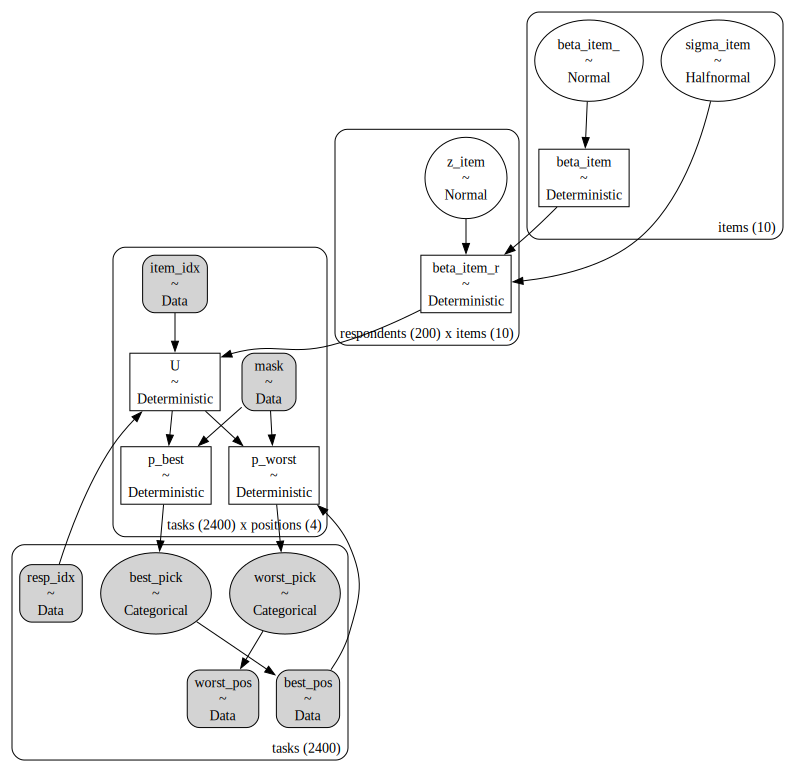

In [8]:
pm.model_to_graphviz(model.model)

## Parameter recovery

Plot posterior item utilities against the ground truth. The dashed 45° line is perfect recovery.


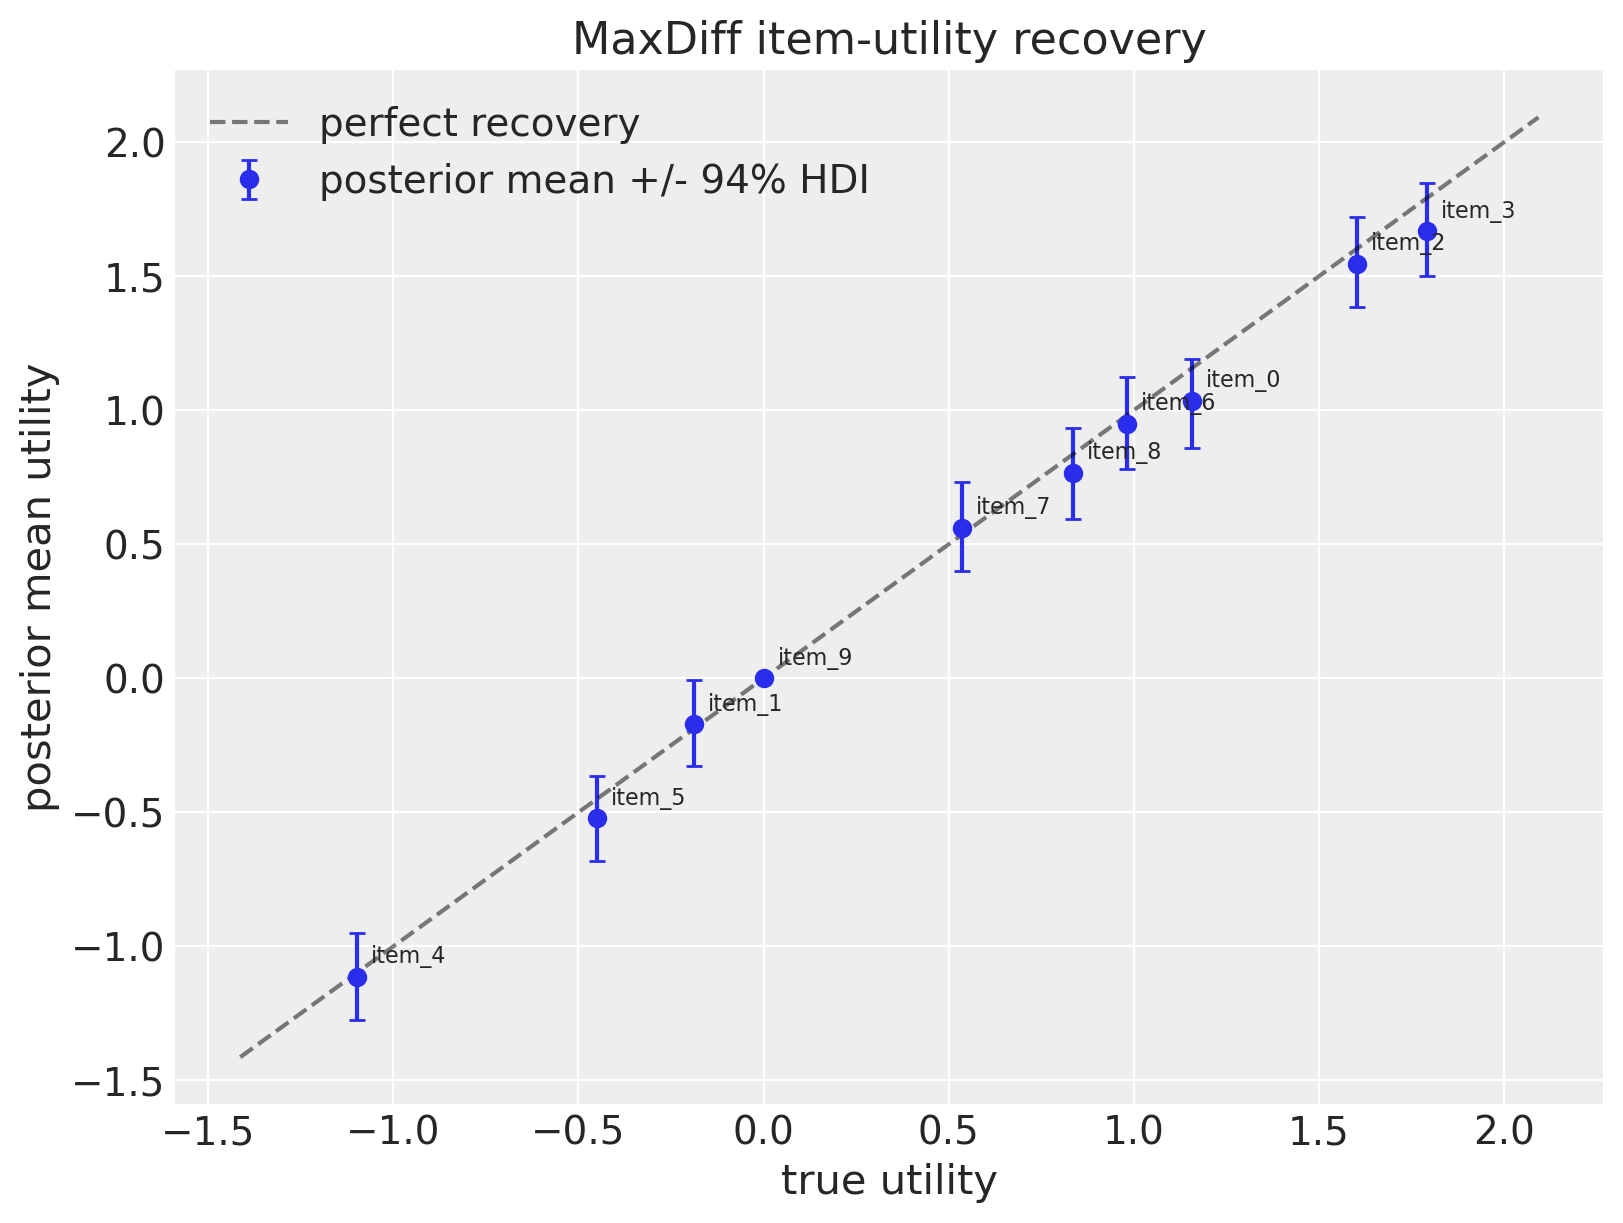

In [9]:
posterior = idata["posterior"]["beta_item"]
post_mean = posterior.mean(dim=("chain", "draw")).values
post_hdi = az.hdi(posterior, hdi_prob=0.94)["beta_item"].values  # (items, 2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    true_utilities,
    post_mean,
    yerr=np.abs(post_hdi.T - post_mean),
    fmt="o",
    capsize=3,
    label="posterior mean +/- 94% HDI",
)
lo = min(true_utilities.min(), post_mean.min()) - 0.3
hi = max(true_utilities.max(), post_mean.max()) + 0.3
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5, label="perfect recovery")
for i, name in enumerate(items):
    ax.annotate(
        name,
        (true_utilities[i], post_mean[i]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.set_xlabel("true utility")
ax.set_ylabel("posterior mean utility")
ax.set_title("MaxDiff item-utility recovery")
ax.legend()
plt.show()

In [10]:
az.summary(idata, var_names=["beta_item", "sigma_item"], round_to=2)

/Users/nathanielforde/mambaforge/envs/pymc-marketing-dev/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/nathanielforde/mambaforge/envs/pymc-marketing-dev/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_item[item_0],1.04,0.09,0.86,1.19,0.00,0.00,1787.81,2600.43,1.00
beta_item[item_1],-0.17,0.09,-0.33,-0.01,0.00,0.00,1895.50,2439.09,1.00
beta_item[item_2],1.55,0.09,1.39,1.72,0.00,0.00,1676.33,2549.83,1.00
beta_item[item_3],1.67,0.09,1.50,1.85,0.00,0.00,1774.31,2505.83,1.00
beta_item[item_4],-1.11,0.09,-1.27,-0.95,0.00,0.00,2125.91,2935.83,1.00
beta_item[item_5],-0.52,0.08,-0.68,-0.37,0.00,0.00,1869.86,2534.21,1.00
beta_item[item_6],0.95,0.09,0.78,1.12,0.00,0.00,1747.63,2593.37,1.00
beta_item[item_7],0.56,0.09,0.40,0.73,0.00,0.00,1642.00,2410.61,1.00
beta_item[item_8],0.77,0.09,0.59,0.93,0.00,0.00,1630.01,2391.22,1.00
beta_item[item_9],0.00,0.00,0.00,0.00,0.00,NaN,4000.00,4000.00,NaN


## Respondent heterogeneity

`beta_item_r` holds per-respondent item utilities. A forest of the first few respondents shows
how strongly preferences vary — the motivation for the hierarchical layer.


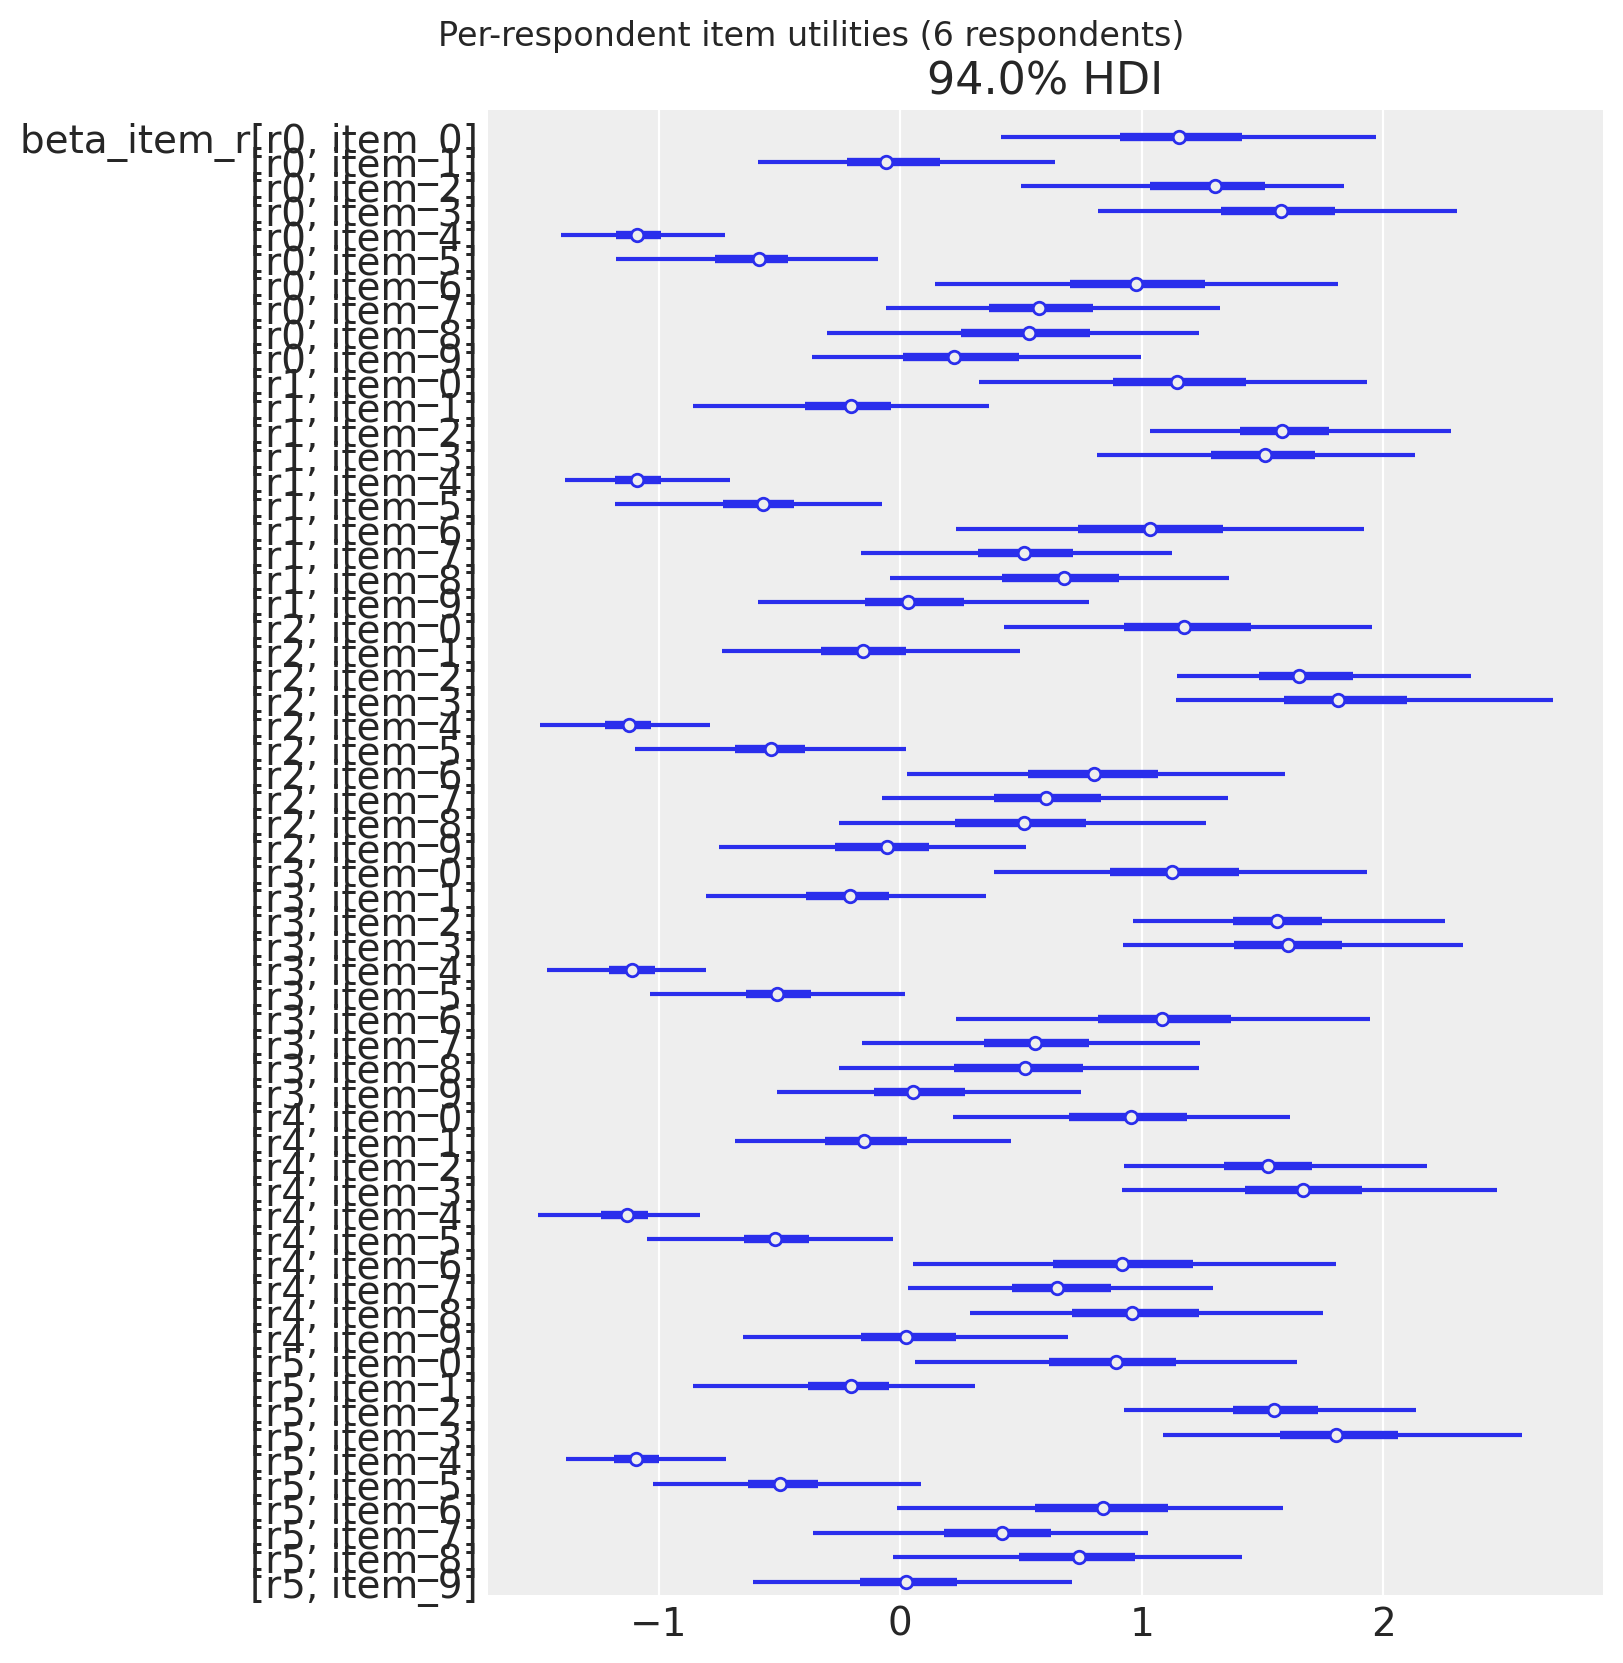

In [11]:
resp_sample = idata["posterior"]["beta_item_r"].isel(respondents=slice(0, 6))
az.plot_forest(
    resp_sample,
    combined=True,
    figsize=(8, 8),
)
plt.suptitle("Per-respondent item utilities (6 respondents)", y=1.02)
plt.show()

## Share of preference

The common consulting deliverable: given the posterior utilities, what fraction of respondents
would pick each item if all items were shown together? This is just the softmax of the posterior
item utilities averaged over draws.


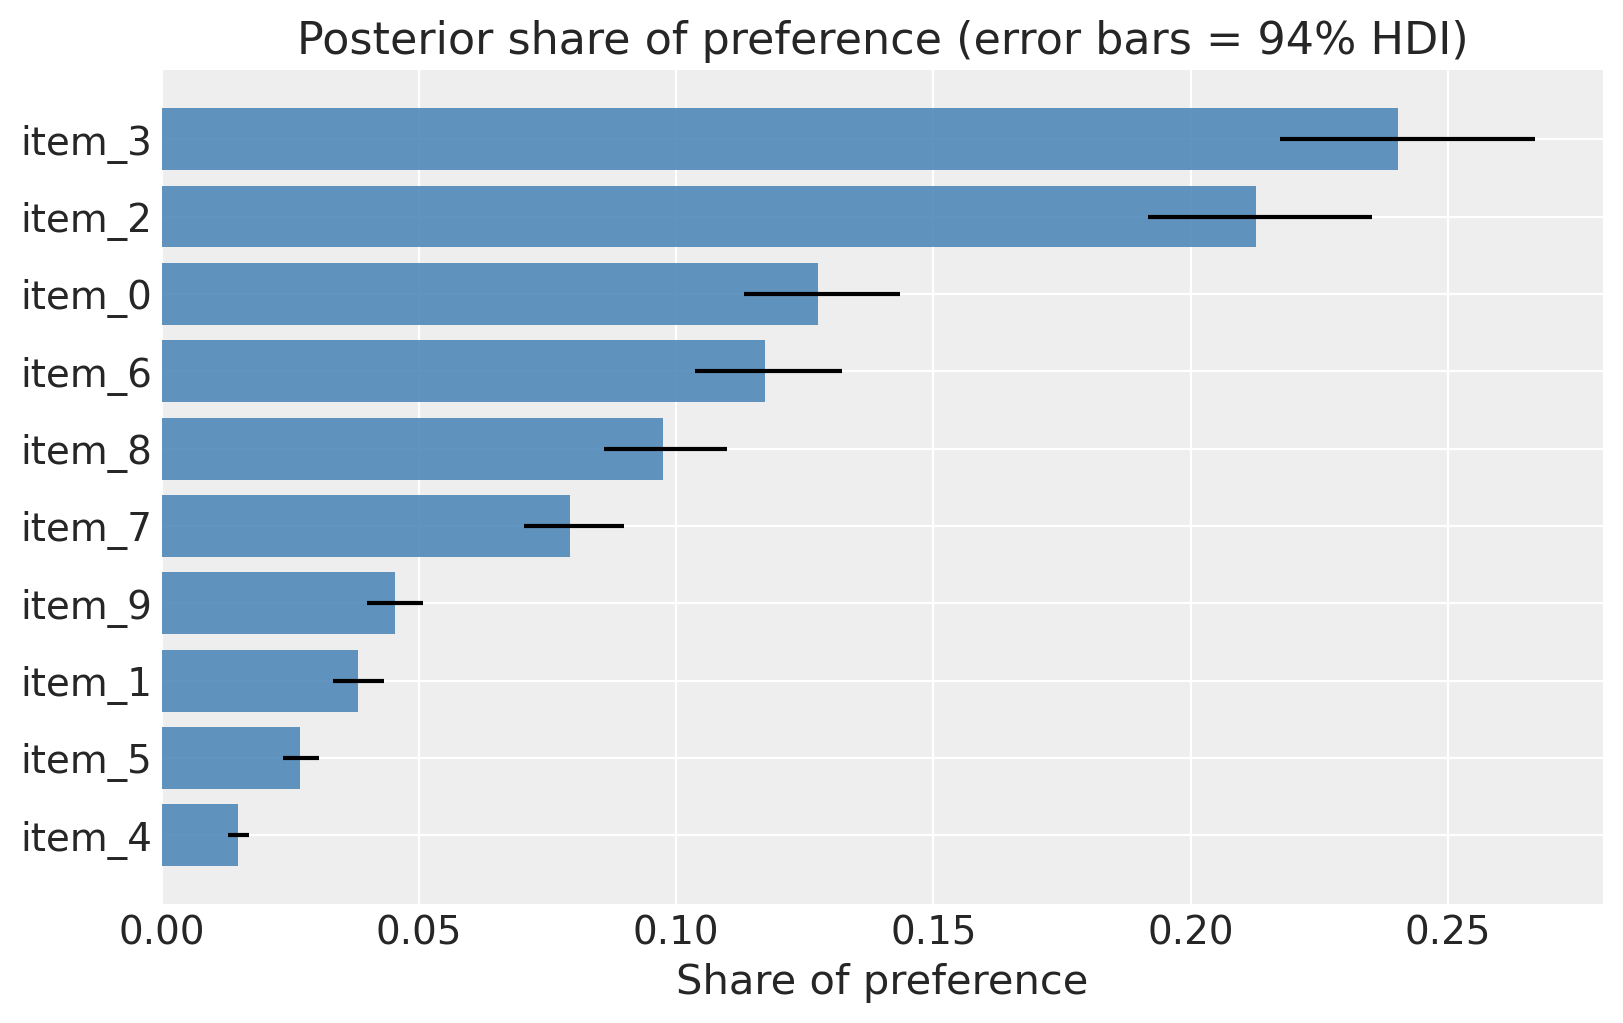

In [12]:
beta_draws = (
    idata["posterior"]["beta_item"].stack(sample=("chain", "draw")).values
)  # (items, samples)
# Softmax across items for each draw
beta_shift = beta_draws - beta_draws.max(axis=0, keepdims=True)
exp_b = np.exp(beta_shift)
shares = exp_b / exp_b.sum(axis=0, keepdims=True)  # (items, samples)

share_mean = shares.mean(axis=1)
share_hdi = np.quantile(shares, [0.03, 0.97], axis=1)

order = np.argsort(share_mean)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(items))
ax.barh(
    y_pos,
    share_mean[order],
    xerr=np.abs(share_hdi[:, order] - share_mean[order]),
    color="steelblue",
    alpha=0.85,
)
ax.set_yticks(y_pos)
ax.set_yticklabels([items[i] for i in order])
ax.invert_yaxis()
ax.set_xlabel("Share of preference")
ax.set_title("Posterior share of preference (error bars = 94% HDI)")
plt.show()

## Counterfactual: restricted-assortment share of preference

A real business question: *if we discontinued items 7, 8 and 9, how would demand shift to the
survivors?* This is a genuinely out-of-sample prediction — the restricted assortment was never
shown during the survey.

`predict_choices` answers it by building a synthetic task where every respondent is shown the
counterfactual item set, then generatively sampling per-respondent best (and worst) picks from
the posterior. Because `beta_item_r` captures per-respondent preferences, the resulting
substitution pattern is **preference-weighted** — respondents who liked a dropped item don't
all move to the same survivor.

The comparison below contrasts this against the naive baseline that simply renormalises the
full-pool shares over the restricted set — the sort of answer you'd get without a choice model.

In [ ]:
import pandas as pd

# Counterfactual assortment: items 3, 8, 9 are discontinued.
dropped = {"item_3", "item_2", "item_9"}
restricted_items = [it for it in items if it not in dropped]
print(f"Restricted assortment ({len(restricted_items)} items): {restricted_items}")

# Build a counterfactual task_df: every respondent sees the restricted set in one task.
# No is_best / is_worst columns needed -- apply_intervention auto-generates dummy flags.
cf_rows = []
for r in task_df["respondent_id"].unique():
    for it in restricted_items:
        cf_rows.append(
            {
                "respondent_id": r,
                "task_id": 0,
                "item_id": it,
            }
        )
cf_df = pd.DataFrame(cf_rows)

# apply_intervention wraps predict_choices and stores the result as model.intervention_idata.
cf_preds = model.apply_intervention(cf_df, random_seed=SEED)

# best_pick shape: (chain, draw, tasks). Here tasks == n_respondents.
best_positions = cf_preds["best_pick"].values
restricted_arr = np.array(restricted_items)
best_item_per_draw = restricted_arr[best_positions]  # (chain, draw, respondents)

# Model-based share: fraction of (chain, draw, respondent) picks per item.
cf_share_per_draw = np.stack(
    [(best_item_per_draw == it).mean(axis=-1) for it in restricted_items]
)  # (items, chain, draw)
cf_share_mean = cf_share_per_draw.mean(axis=(1, 2))
cf_share_hdi = np.quantile(
    cf_share_per_draw.reshape(len(restricted_items), -1), [0.03, 0.97], axis=1
)
print("------ Counterfactual Share ------")
print(cf_share_mean)

# Naive baseline: renormalise full-pool shares over the restricted set.
full_share_map = dict(zip(items, share_mean, strict=True))
naive_share = np.array([full_share_map[it] for it in restricted_items])
naive_share = naive_share / naive_share.sum()
print("------- Naive Share -------")
print(naive_share)

/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_11591/2766163016.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


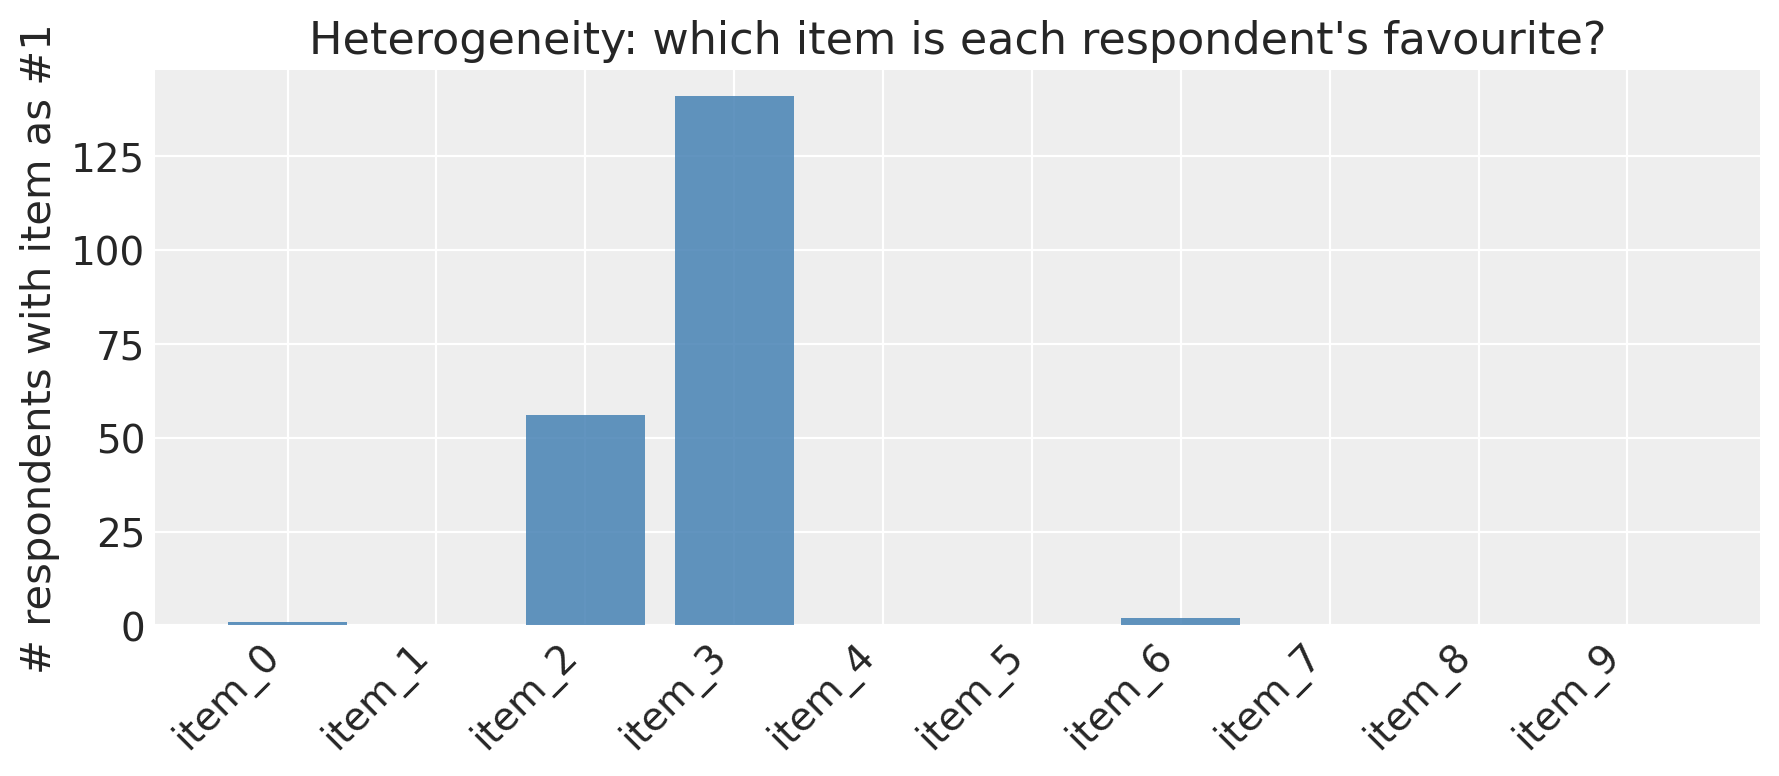

In [14]:
beta_r_mean = (
    idata["posterior"]["beta_item_r"].mean(dim=("chain", "draw")).values
)  # (R, I)
top_item_idx = np.argmax(beta_r_mean, axis=1)
top_item_counts = (
    pd.Series([items[i] for i in top_item_idx], name="top_item")
    .value_counts()
    .reindex(items, fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(items)), top_item_counts.values, color="steelblue", alpha=0.85)
ax.set_xticks(range(len(items)))
ax.set_xticklabels(top_item_counts.index, rotation=45, ha="right")
ax.set_ylabel("# respondents with item as #1")
ax.set_title("Heterogeneity: which item is each respondent's favourite?")
plt.tight_layout()
plt.show()

## Caveats and follow-ups

- **Design**: real MaxDiff studies use balanced incomplete block designs (Sawtooth/Lighthouse).
  This model does not care which design produced the data — but efficiency is much higher
  under balanced rotations.
- **Item-attribute part-worths**: when items share structure (price, brand, feature levels),
  a linear utility over item covariates $U_j = x_j^\top \beta$ gains efficiency.
  — file an issue if you need it.


## Part II — MaxDiff with attribute part-worths

So far each item carried its own free utility. In conjoint-style MaxDiff we instead decompose
utility into **attribute part-worths**:

$$U_i = X_i^\top \beta_{\text{feat}}$$

where $X_i$ is a row of attribute features (brand dummies, price, quality score, …) and
$\beta_{\text{feat}}$ is a vector of population-level part-worths. This buys three things the
item-intercept model cannot give:

1. **Extrapolation to new items.** A hypothetical SKU outside the training pool gets a utility
   from its attributes alone — no need to re-survey.
2. **Attribute-level inference.** The posterior on $\beta_{\text{feat}}$ tells us *what* drives
   preference, not just *which item* is preferred.
3. **Heterogeneity on a chosen subspace.** Pass `random_attributes=[...]` to let respondents
   vary on a strict subset of features (e.g. price sensitivity) while sharing population beliefs
   on the rest.

Identification comes from `~ 0 + ...` in the patsy formula (drop the global intercept) plus a
sum-to-zero constraint on the implied per-item utilities — no reference item is needed.

In [15]:
from pymc_marketing.customer_choice import generate_maxdiff_conjoint_data

task_df_pw, attrs, gt = generate_maxdiff_conjoint_data(
    n_respondents=500,
    n_items=12,
    n_tasks_per_resp=12,
    subset_size=4,
    sigma_respondent=0.4,
    random_attributes=["price"],
    random_seed=SEED,
)

print("Items + attributes:")
print(attrs)
print("\nFeature names (after patsy expansion):", gt["feature_names"])
print("Ground-truth betas:", dict(zip(gt["feature_names"], gt["betas"], strict=True)))

Items + attributes:
        brand     price   quality
item_id                          
item_0      A  0.761140  0.878450
item_1      C  0.786064 -0.049926
item_2      B  0.128114 -0.184862
item_3      B  0.450386 -0.680930
item_4      B  0.370798  1.222541
item_5      C  0.926765 -0.154529
item_6      A  0.643865 -0.428328
item_7      C  0.822762 -0.352134
item_8      A  0.443414  0.532309
item_9      A  0.227239  0.365444
item_10     B  0.554585  0.412733
item_11     C  0.063817  0.430821

Feature names (after patsy expansion): ['C(brand)[A]', 'C(brand)[B]', 'C(brand)[C]', 'price', 'quality']
Ground-truth betas: {'C(brand)[A]': np.float64(2.1416476008704612), 'C(brand)[B]': np.float64(-0.4064150163846156), 'C(brand)[C]': np.float64(-0.5122427290715373), 'price': np.float64(-0.8137727282478777), 'quality': np.float64(0.6159794225754956)}


In [16]:
model_pw = MaxDiffMixedLogit(
    task_df=task_df_pw,
    items=gt["items"],
    item_attributes=attrs,
    utility_formula="~ 0 + C(brand) + price + quality",
    random_attributes=["price"],
)

idata_pw = model_pw.fit(
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.9,
    random_seed=SEED,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


### Recovery — population part-worths

Compare the posterior mean of `beta_feat` against the simulated ground truth. Brand dummies
share an unidentified global location (only contrasts are identified via `~ 0 + ...`), so we
compare *centred* values; price and quality recover on absolute scale.

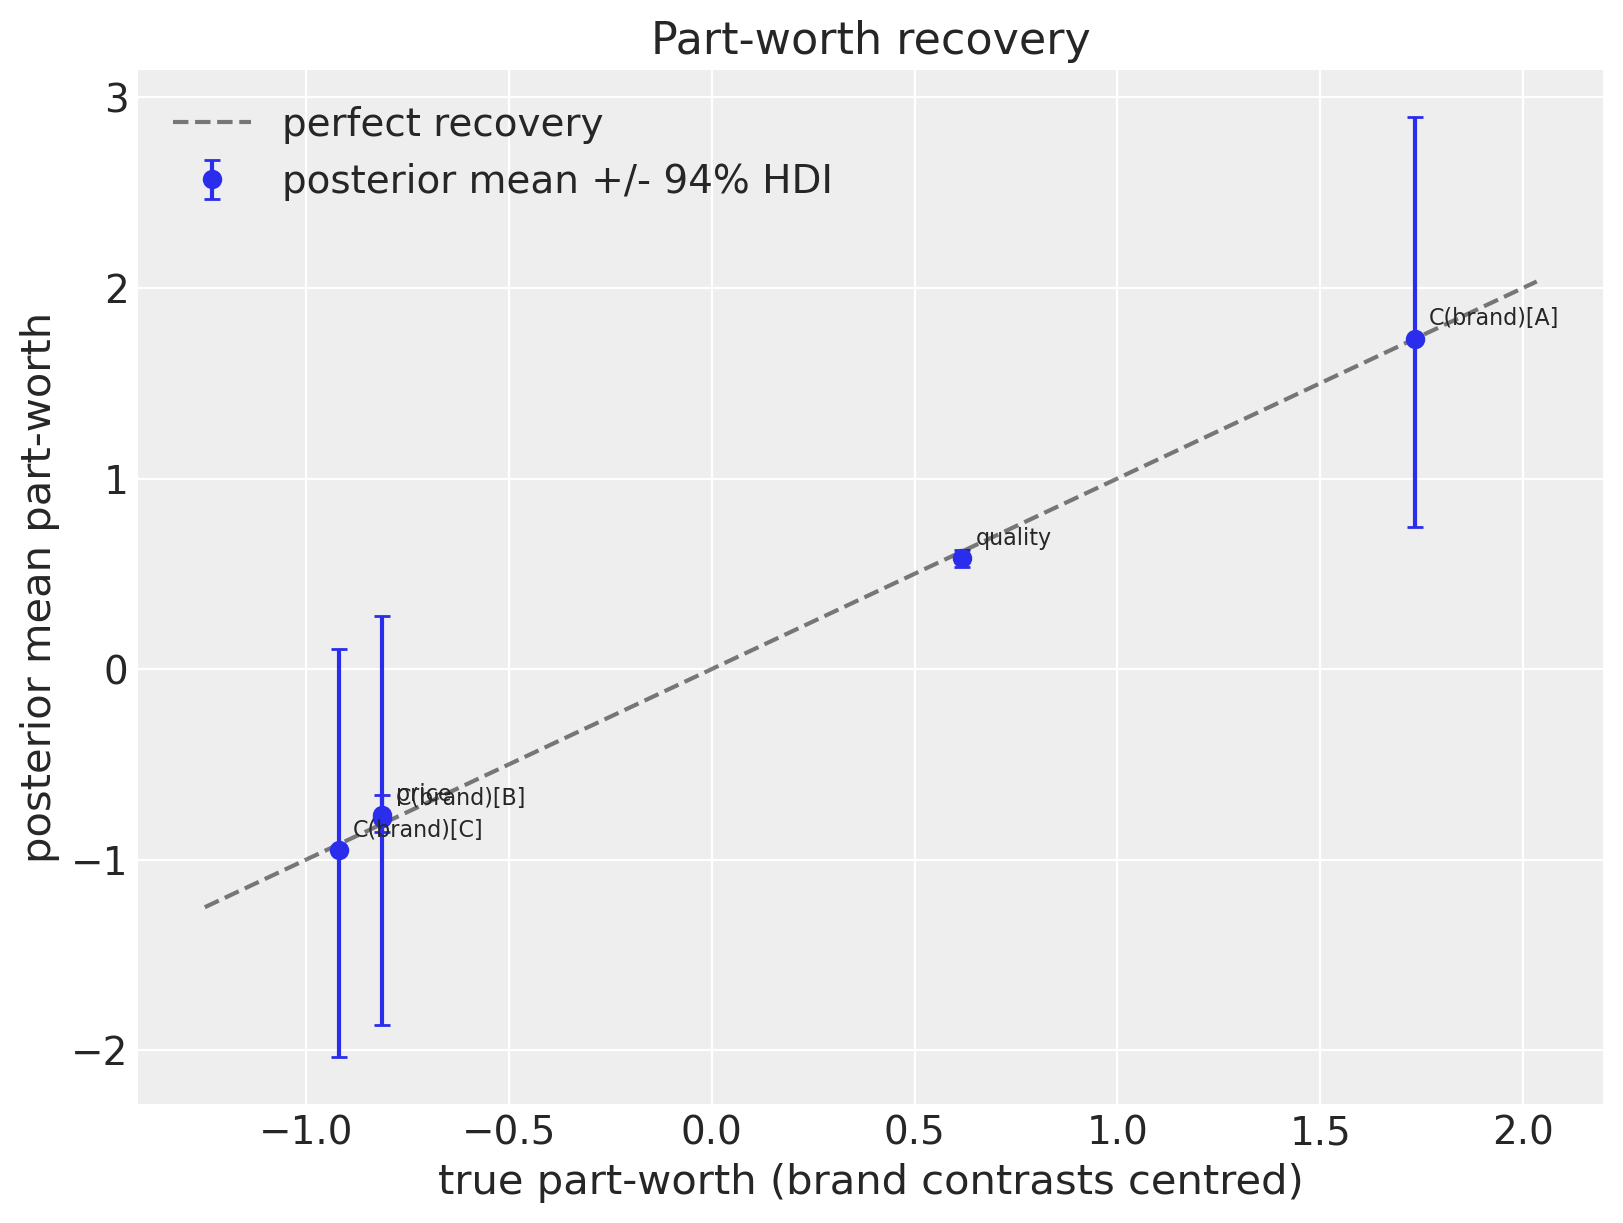

In [17]:
feature_names = model_pw.feature_names
beta_post = idata_pw["posterior"]["beta_feat"]  # (chain, draw, features)
beta_mean = beta_post.mean(dim=("chain", "draw")).values
beta_hdi = az.hdi(beta_post, hdi_prob=0.94)["beta_feat"].values  # (features, 2)
truth = np.asarray(gt["betas"])

# Centre brand dummies (location is unidentified within the brand group).
is_brand = np.array([f.startswith("C(brand)") for f in feature_names])
truth_plot = truth.copy()
mean_plot = beta_mean.copy()
hdi_plot = beta_hdi.copy()
truth_plot[is_brand] -= truth_plot[is_brand].mean()
mean_plot[is_brand] -= mean_plot[is_brand].mean()
hdi_plot[is_brand] -= mean_plot[is_brand].mean()  # shift HDI by same amount

fig, ax = plt.subplots(figsize=(8, 6))
yerr = np.abs(hdi_plot.T - mean_plot)
ax.errorbar(
    truth_plot,
    mean_plot,
    yerr=yerr,
    fmt="o",
    capsize=3,
    label="posterior mean +/- 94% HDI",
)
lo = min(truth_plot.min(), mean_plot.min()) - 0.3
hi = max(truth_plot.max(), mean_plot.max()) + 0.3
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5, label="perfect recovery")
for i, name in enumerate(feature_names):
    ax.annotate(
        name,
        (truth_plot[i], mean_plot[i]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )
ax.set_xlabel("true part-worth (brand contrasts centred)")
ax.set_ylabel("posterior mean part-worth")
ax.set_title("Part-worth recovery")
ax.legend()
plt.show()

In [18]:
az.summary(
    idata_pw,
    var_names=["beta_feat", "U_item_pop", "sigma_feat"],
    round_to=2,
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_feat[C(brand)[A]],1.75,0.57,0.74,2.90,0.01,0.01,2143.69,2599.75,1.00
beta_feat[C(brand)[B]],-0.76,0.57,-1.87,0.28,0.01,0.01,2125.97,2666.44,1.00
beta_feat[C(brand)[C]],-0.93,0.57,-2.04,0.10,0.01,0.01,2129.16,2572.53,1.00
beta_feat[price],-0.76,0.05,-0.85,-0.66,0.00,0.00,6327.23,3180.85,1.00
beta_feat[quality],0.58,0.02,0.54,0.62,0.00,0.00,8839.79,2870.81,1.00
U_item_pop[item_0],1.96,0.03,1.90,2.02,0.00,0.00,4899.11,2983.91,1.00
U_item_pop[item_1],-1.28,0.02,-1.32,-1.24,0.00,0.00,4533.78,3495.03,1.00
U_item_pop[item_2],-0.69,0.03,-0.74,-0.65,0.00,0.00,5134.33,3512.55,1.00
U_item_pop[item_3],-1.23,0.03,-1.28,-1.18,0.00,0.00,5952.63,3021.49,1.00
U_item_pop[item_4],-0.06,0.03,-0.12,-0.00,0.00,0.00,6390.66,3495.47,1.00


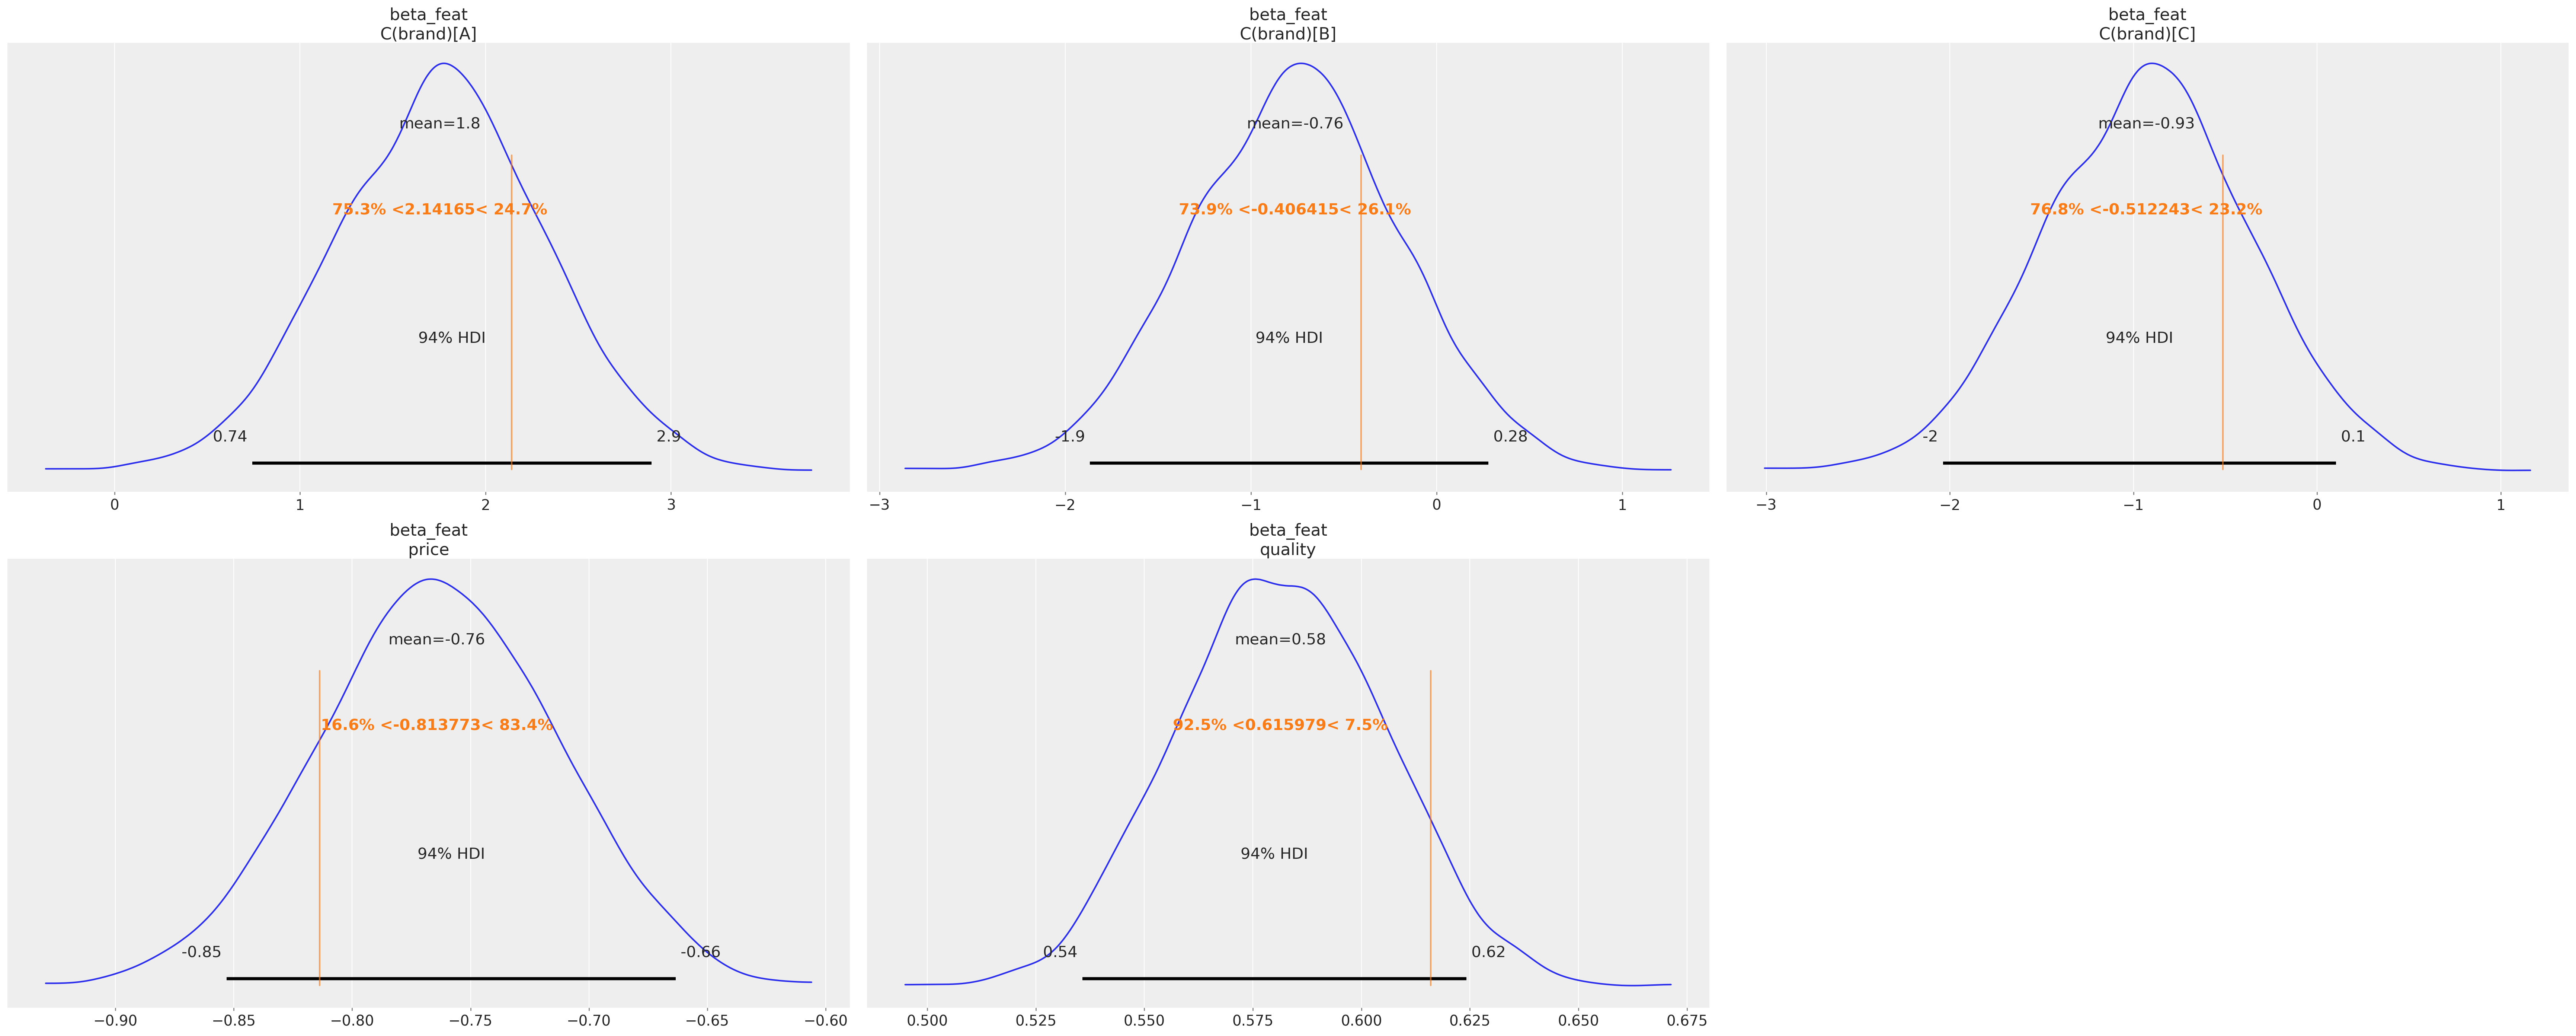

In [19]:
az.plot_posterior(
    idata_pw,
    var_names=["beta_feat"],
    ref_val=list(gt["betas"]),
);

### Attribute importance

A standard conjoint deliverable. Within each attribute, take the *range* of part-worths
(max − min across its levels for categoricals, or the part-worth times the observed
range for continuous attributes), then normalise so the importances sum to 1.

/var/folders/__/ng_3_9pn1f11ftyml_qr69vh0000gn/T/ipykernel_11591/3410986749.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


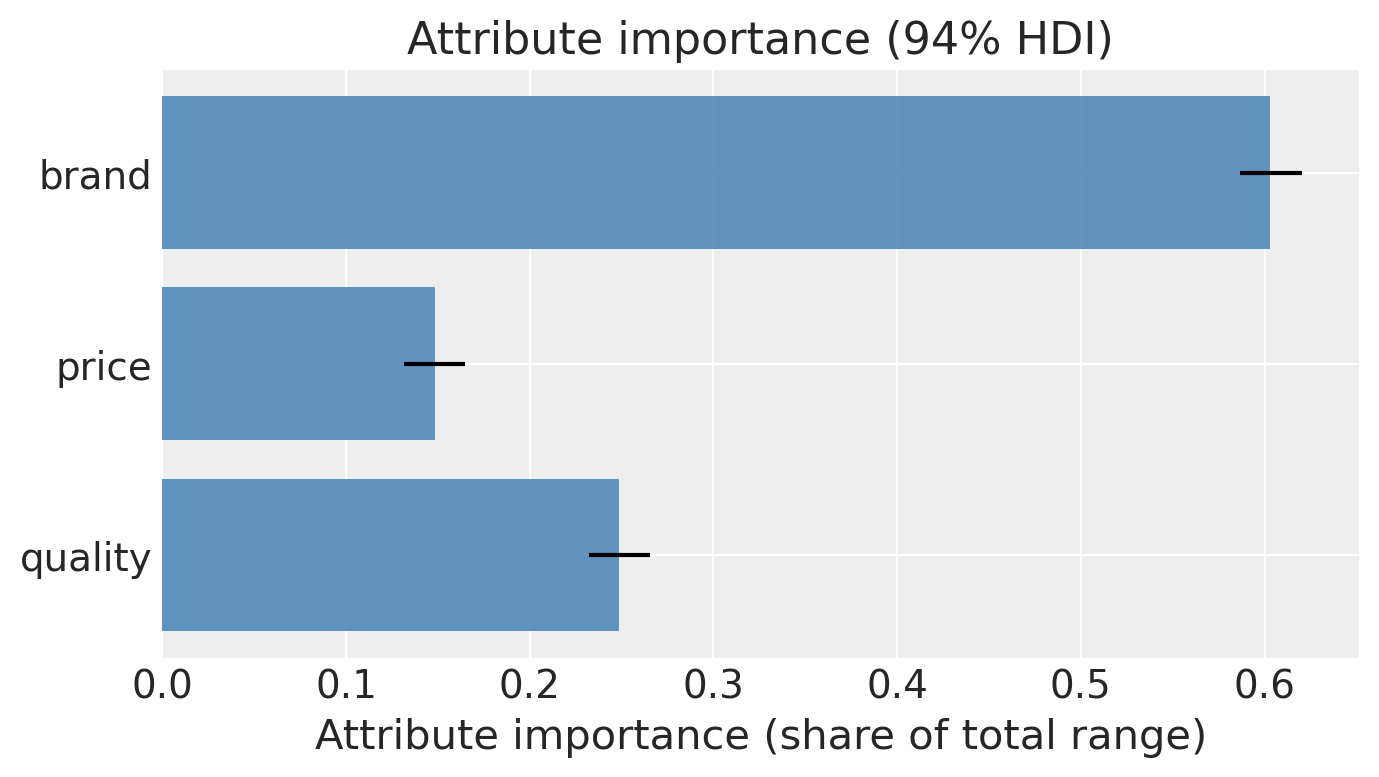

In [20]:
# Posterior draws of beta_feat, shape (samples, features)
beta_draws_pw = (
    idata_pw["posterior"]["beta_feat"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "features")
    .values
)

attr_groups = {
    "brand": [i for i, f in enumerate(feature_names) if f.startswith("C(brand)")],
    "price": [feature_names.index("price")],
    "quality": [feature_names.index("quality")],
}
# Continuous attributes: importance = |beta| * (observed range across items)
ranges = {
    "price": float(attrs["price"].max() - attrs["price"].min()),
    "quality": float(attrs["quality"].max() - attrs["quality"].min()),
}

importance_draws = {}
for name, idxs in attr_groups.items():
    if name == "brand":
        # Range of brand part-worths per draw
        importance_draws[name] = beta_draws_pw[:, idxs].max(axis=1) - beta_draws_pw[
            :, idxs
        ].min(axis=1)
    else:
        importance_draws[name] = np.abs(beta_draws_pw[:, idxs[0]]) * ranges[name]

stack = np.stack([importance_draws[k] for k in attr_groups])  # (3, samples)
shares = stack / stack.sum(axis=0, keepdims=True)  # normalise per draw
share_mean_pw = shares.mean(axis=1)
share_hdi_pw = np.quantile(shares, [0.03, 0.97], axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    list(attr_groups),
    share_mean_pw,
    xerr=np.abs(share_hdi_pw - share_mean_pw),
    color="steelblue",
    alpha=0.85,
)
ax.set_xlabel("Attribute importance (share of total range)")
ax.set_title("Attribute importance (94% HDI)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Extrapolation to a brand-new item

A unique selling point of part-worths: we can score a hypothetical SKU that was *never shown
in the survey*. We just need its attribute row. Apply the same patsy formula to the new row and
use the posterior of `beta_feat` to get a full posterior over the new item's utility — which
plugs directly into a share-of-preference calculation against the existing items.

In [ ]:
# Score a brand-new item: brand "B", aggressive price 0.10, average quality 0.0.
new_item = pd.DataFrame(
    [{"brand": "B", "price": 0.10, "quality": 0.0}],
    index=pd.Index(["item_NEW"], name="item_id"),
)

# score_new_items encodes the new row via the fitted patsy formula, computes posterior
# utilities from beta_feat, and returns share-of-preference over the extended pool.
scored = model_pw.score_new_items(new_item)

# scored.coords["items"] = training items + ["item_NEW"]
all_items = list(scored.coords["items"].values)
share_mean_new = scored["share_of_preference"].mean(dim=("chain", "draw")).values
share_hdi_new = np.quantile(
    scored["share_of_preference"].values.reshape(len(all_items), -1).T,
    [0.03, 0.97],
    axis=0,
)

order_new = np.argsort(share_mean_new)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(all_items))
colors = [
    "darkorange" if all_items[i] == "item_NEW" else "steelblue" for i in order_new
]
ax.barh(
    y_pos,
    share_mean_new[order_new],
    xerr=np.abs(share_hdi_new[:, order_new] - share_mean_new[order_new]),
    color=colors,
    alpha=0.85,
)
ax.set_yticks(y_pos)
ax.set_yticklabels([all_items[i] for i in order_new])
ax.invert_yaxis()
ax.set_xlabel("Share of preference")
ax.set_title("Share of preference incl. brand-new SKU 'item_NEW' (orange)")
plt.tight_layout()
plt.show()

new_idx = all_items.index("item_NEW")
print(
    f"New item posterior share: mean={share_mean_new[new_idx]:.3f}, "
    f"94% HDI=[{share_hdi_new[0, new_idx]:.3f}, {share_hdi_new[1, new_idx]:.3f}]"
)

### Production notes

**Counterfactual API** — two intervention methods mirror the pattern of the other customer-choice models:

- **`model.apply_intervention(new_task_df, ...)`** — Type 1 intervention: swap in a new task design (e.g. drop items from the assortment, show a subset to a fresh panel). Dummy `is_best` / `is_worst` flags are auto-generated if both are absent from `new_task_df`.
- **`model_pw.score_new_items(new_item_attributes)`** — Type 2 intervention (part-worths mode only): introduce hypothetical SKUs not seen during training. Uses the fitted patsy formula to encode their attributes and returns posterior share-of-preference over the extended item pool.

**Scaling knobs** — two `predict_choices` kwargs (exposed through `apply_intervention` as well):

- **`new_respondents="population"`** — for each respondent in the counterfactual `task_df` that was *not* in the training survey, draw a fresh respondent-level utility vector from the fitted population distribution. Standard mixed-logit extrapolation to a representative new customer.
- **`draw_batch_size=N`** — compute per-task utilities in chunks of `N` posterior draws rather than materialising the full `(chain, draw, tasks, positions)` tensor at once. Keeps peak memory bounded for large counterfactual designs. Output is bit-identical to the unbatched path for a given `random_seed`.

```python
preds = model_pw.apply_intervention(
    big_counterfactual_task_df,
    new_respondents="population",
    draw_batch_size=100,
    random_seed=SEED,
)
```